In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [3]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
X = df[feature_names]
y = df['Heating Load']

# 70/30 train-test split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit scaler on training data only, then apply to both sets
# Fitting on the test set would leak test statistics into the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on train
X_test_scaled = scaler.transform(X_test)         # transform only, no refit

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples : {X_test.shape[0]}')
print(f'Features : {X_train.shape[1]}')

Training samples : 537
Test samples : 231
Features : 8


In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [ ]:
from scipy.linalg import lstsq

# Fit OLS model as a no-regularisation baseline
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

# Workaround for an Apple Silicon BLAS issue that gives unstable OLS coefficients.
# Refit using scipy's gelsd driver to match the workbench result.
X_aug = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
coef_full, *_ = lstsq(X_aug, y_train, lapack_driver='gelsd') # Specify working driver
ols.intercept_ = coef_full[0]
ols.coef_ = coef_full[1:]

# Predict on the held-out test set and compute MSE
mse_ols = mean_squared_error(y_test, ols.predict(X_test_scaled))
print(f'OLS Test MSE: {mse_ols:.3f}')

# Display coefficients for each predictor
ols_coef = pd.Series(ols.coef_, index=feature_names)
print('\nOLS Coefficients:')
print(ols_coef.to_string())

OLS Test MSE: 8.840

OLS Coefficients:
Relative Compactness        -6.686924
Surface Area                -3.701472
Wall Area                    0.761142
Roof Area                   -3.992429
Overall Height               7.216818
Orientation                 -0.026067
Glazing Area                 2.670032
Glazing Area Distribution    0.356042


In [7]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [8]:
# Define the grid of regularisation strengths
lambdas = np.logspace(-4, 4, 100) # logspace(-4, 4) gives 100 values evenly spaced on a log scale from 0.0001 to 10000

# Perform 10 fold cross-validation for each lambda and retain the model with the best (lowest) CV MSE
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

print(f'Best lambda (alpha) chosen by CV: {ridge_cv.alpha_:.4f}')

# Build a side-by-side coefficient comparison table: OLS vs Ridge
coef_table = pd.DataFrame({
    'Feature'         : feature_names,
    'OLS Coefficient' : ols.coef_,
    'Ridge Coefficient': ridge_cv.coef_
})
coef_table

Best lambda (alpha) chosen by CV: 0.2057


,Feature,OLS Coefficient,Ridge Coefficient
0,Relative Compactness,-6.686924,-6.352418
1,Surface Area,-3.701472,-3.474392
2,Wall Area,0.761142,0.816587
3,Roof Area,-3.992429,-3.797180
4,Overall Height,7.216818,7.306373
5,Orientation,-0.026067,-0.025299
6,Glazing Area,2.670032,2.670852
7,Glazing Area Distribution,0.356042,0.356417


In [9]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

Yes, the Ridge penalty is doing its job. Looking at the coefficient table, every predictor got slightly smaller under Ridge compared to OLS, none got larger. The changes are small because the OLS coefficients were already reasonable on this dataset, which is why cross validation picked a small lambda of 0.2057. For example, Relative Compactness went from -6.69 to -6.35, and Surface Area from -3.70 to -3.47. The shrinkage is subtle but consistent across all features, which is exactly what the Ridge penalty is supposed to do.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [10]:
# Use the cross-validated Ridge model to generate predictions on the held-out test set
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# Compute test MSE for the Ridge model
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)
print(f'Ridge CV Test MSE: {mse_rcv:.3f}')

Ridge CV Test MSE: 8.844


In [11]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

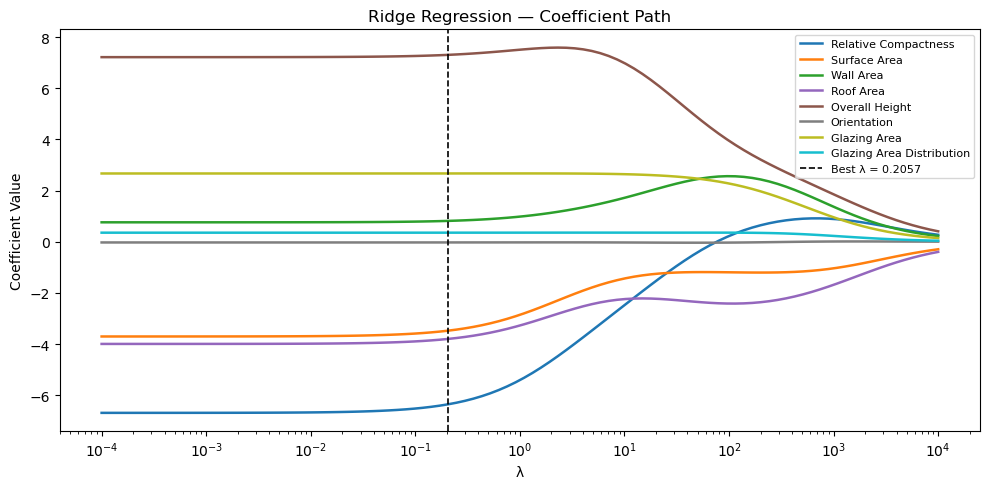

In [12]:
# Fit a Ridge model for every lambda in the search grid to trace coefficient paths
coef_paths = np.array([
    Ridge(alpha=lam).fit(X_train_scaled, y_train).coef_ # row of coef_paths corresponds to one lambda; columns correspond to features
    for lam in lambdas
])

# Colour palette, one colour per feature for readability
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

plt.figure(figsize=(10, 5))
for j, (name, color) in enumerate(zip(feature_names, colors)):
    plt.plot(lambdas, coef_paths[:, j], label=name, color=color, linewidth=1.8)

# Mark lambda selected by cross-validation
plt.axvline(ridge_cv.alpha_, color='black', linestyle='--', linewidth=1.2,
            label=f'Best λ = {ridge_cv.alpha_:.4f}')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression — Coefficient Path')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

**Overall Height** and **Relative Compactness** are the two most important predictors.

Overall Height (brown line) stays near the top of the chart across almost the whole range of lambda values and is one of the last lines to shrink toward zero. Relative Compactness (blue line) does the same thing on the negative side, staying around -6 to -7 for a long time before finally dropping.

The bigger the penalty Ridge needs before a line flattens out to zero, the more important that feature is. Overall Height and Relative Compactness resist shrinkage the longest, so they are carrying the most real information about heating load.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [13]:
# Apply 10 fold CV but with an L1 penalty
lasso_cv = LassoCV(alphas=lambdas, cv=10) # L1 can shrink some coefficients to exactly zero, performing automatic variable selection
lasso_cv.fit(X_train_scaled, y_train)

print(f'Best lambda (alpha) chosen by CV: {lasso_cv.alpha_:.4f}')

# Side-by-side comparison: OLS vs Lasso coefficients
lasso_coef_table = pd.DataFrame({
    'Feature'          : feature_names,
    'OLS Coefficient'  : ols.coef_,
    'Lasso Coefficient': lasso_cv.coef_
})
lasso_coef_table

Best lambda (alpha) chosen by CV: 0.0016


,Feature,OLS Coefficient,Lasso Coefficient
0,Relative Compactness,-6.686924,-6.418330
1,Surface Area,-3.701472,-6.231035
2,Wall Area,0.761142,2.152524
3,Roof Area,-3.992429,-1.044324
4,Overall Height,7.216818,7.309160
5,Orientation,-0.026067,-0.023593
6,Glazing Area,2.670032,2.670194
7,Glazing Area Distribution,0.356042,0.354971


In [14]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Lasso did not shrink the coefficients in the same way Ridge did. The differences are quite noticeable here.

Ridge shrank every coefficient a little bit in the same direction, every predictor got slightly smaller compared to OLS. Lasso behaved differently. Some coefficients did get smaller (Relative Compactness, Roof Area, Orientation), but others actually got larger or flipped (Surface Area went from -3.70 to -6.23 and Wall Area went from 0.76 to 2.15). This happens because Lasso redistributes weight across correlated features rather than just uniformly shrinking them all. Orientation is nearly zero (-0.02), meaning Lasso is close to dropping it from the model entirely. Ridge never removes any feature, it just makes all of them a little smaller. Lasso can push a coefficient all the way to zero and eliminate that feature, though it didn't fully do that here.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [15]:
# Predict on the held-out test set using the cross-validated Lasso model
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# Compute test MSE for Lasso
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)
print(f'Lasso CV Test MSE: {mse_lcv:.3f}')

Lasso CV Test MSE: 8.842


In [16]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [17]:
# Table: Test MSE for OLS, Ridge CV, and Lasso CV
mse_table = pd.DataFrame({
    'Model'   : ['OLS', 'Ridge CV', 'Lasso CV'],
    'Test MSE': [mse_ols, mse_rcv, mse_lcv]
})
print(mse_table.to_string(index=False))

   Model  Test MSE
     OLS  8.839503
Ridge CV  8.843961
Lasso CV  8.841571


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

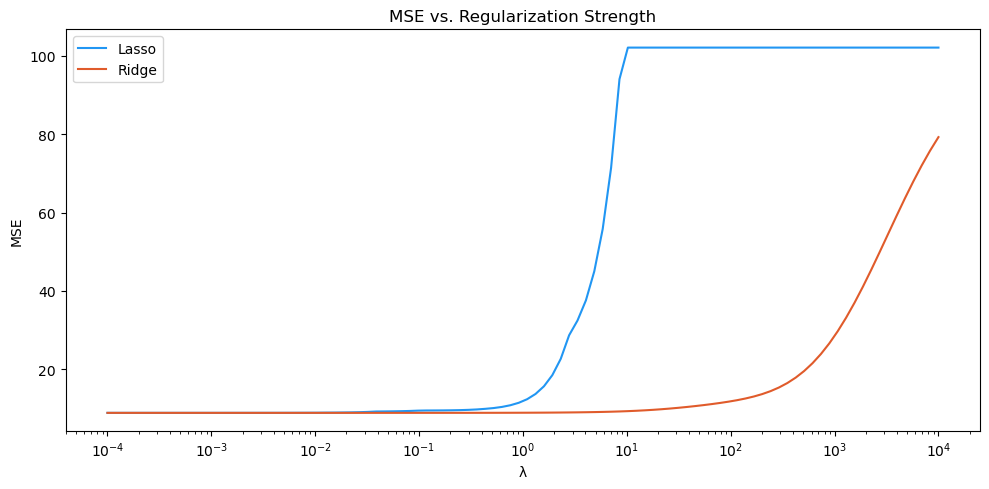

In [ ]:
# Recompute test MSE across the full lambda grid for both models
mse_lasso_path = []
mse_ridge_path = []

for lam in lambdas:
    lasso = Lasso(alpha=lam)
    ridge = Ridge(alpha=lam)
    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)
    # Evaluate each model on the test set at this lambda
    mse_lasso_path.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    mse_ridge_path.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso_path, label='Lasso', color='#2196F3')
plt.plot(lambdas, mse_ridge_path, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

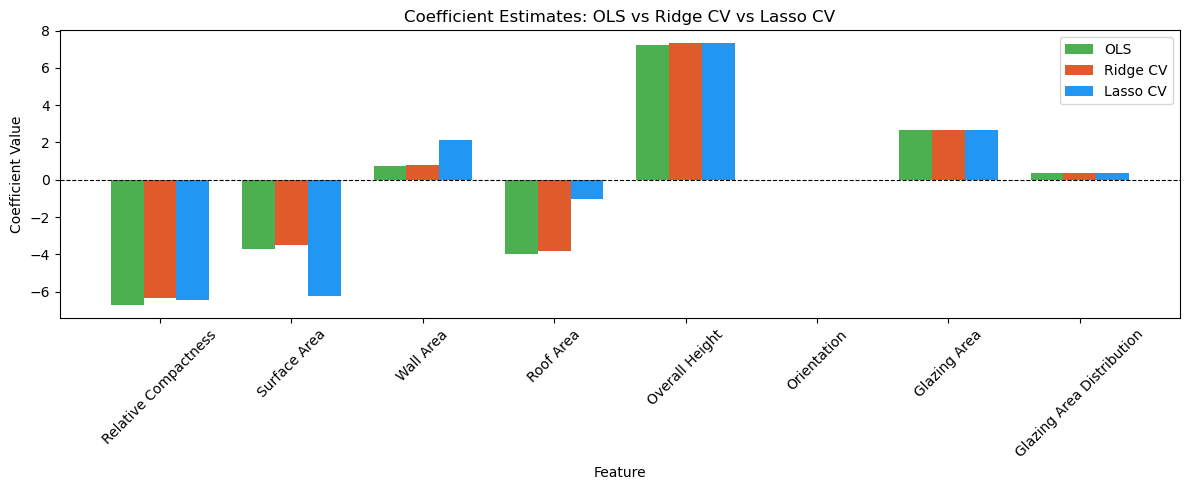

In [19]:
# Bar plot showing how coefficient estimates differ for OLS, Lasso CV and Ridge CV
x = np.arange(len(feature_names))
width = 0.25  # width of each bar group

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, ols.coef_,      width, label='OLS',      color='#4CAF50')
ax.bar(x,         ridge_cv.coef_, width, label='Ridge CV', color='#E05B2B')
ax.bar(x + width, lasso_cv.coef_, width, label='Lasso CV', color='#2196F3')

ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Feature')
ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Estimates: OLS vs Ridge CV vs Lasso CV')
ax.legend()
plt.tight_layout()
plt.show()

> **Q4: Which model would you pick for this dataset? Why?**

Looking at the MSE table, all three models perform almost exactly the same. The differences are so small they don't really matter. Therefore, I would pick **Ridge CV**.

*Reason*
The MSE plot shows that Lasso's error jumps up sharply once lambda gets too large, while Ridge stays flat and stable for much longer. This means if we pick a slightly wrong lambda for Lasso, our predictions can get much worse very quickly. Ridge is more forgiving of that. The bar chart also shows that Lasso moved some coefficients in unexpected directions compared to OLS (for example Surface Area got a bigger negative number and Wall Area got larger). Ridge kept everything close to the OLS values, just nudged slightly smaller, which is easier to trust.

Since all three models give basically the same prediction error, the safer pick is Ridge.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [ ]:
pca_full = ...

explained_var = ...
cumulative_var = ...

explained_var

In [ ]:
grader.check("q7")

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [ ]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = ...

pca_final = ...
X_train_pca = ...
X_test_pca  = ...

ols_pcr = ...

y_pred_pcr = ...
mse_pcr = ...



<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

_Type your answer here, replacing this text._

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [ ]:
grader.check_all()